# Coherent quantum diffusion: non-commuting Hamiltonians

Third in the free-energy series (after `free_energy_qaoa.ipynb` and `quantum_free_energy_flow.ipynb`). So far the cost Hamiltonian was **diagonal**, so the Gibbs state $\rho^*_T\propto e^{-H/T}$ was a classical probability distribution dressed as a density matrix — a *classical* Gibbs sampler could in principle reproduce it. Here we break that: with a **transverse-field Ising** Hamiltonian
$$H \;=\; \sum_{(i,j)\in E} Z_iZ_j \;-\; h\sum_i X_i,$$
the field term does not commute with the computational basis, so $\rho^*_T$ acquires genuine **off-diagonal coherence**. A classical sampler (diagonal states only) *provably cannot* reach it.

Key quantities:
- **Relative entropy of coherence** $C(\rho)=S(\Delta(\rho))-S(\rho)$, where $\Delta$ dephases (zeroes off-diagonals). $C(\rho^*_T)>0$ measures the Gibbs state's quantumness.
- **Classical free energy** $F_{cl}^*=-T\ln\sum_i e^{-H_{ii}/T}$ — the best any diagonal state can do. Since the diagonal of $H$ is just the $ZZ$ part, $F_{cl}^*$ is **independent of $h$**: a classical sampler ignores the transverse field entirely. The gap $F_{cl}^*-F^*\ge0$ is the free energy coherence buys.

**What we test.**
- **Exp D** — the transverse-field Gibbs state is coherent; $C(\rho^*)$ and the quantum–classical gap grow with $h$ (exact).
- **Exp E (the payoff)** — a general (coherent) dissipative flow reaches $F^*$ at all $h$, while a *dephased* flow (a bona-fide classical Gibbs sampler that can still make entropy) floors at the $h$-independent $F_{cl}^*$. The coherent flow does something no classical sampler can.
- **Exp F** — watch the coherent flow *build* coherence, entropy, and fidelity to $\rho^*$ layer by layer.

Exact density-matrix simulation, $n=4$ qubits, fully differentiable (autodiff through `matrix_exp`, partial trace, `eigvalsh`).

In [1]:
import numpy as np, torch, networkx as nx, matplotlib.pyplot as plt, functools, warnings, time
warnings.filterwarnings("ignore"); print = functools.partial(print, flush=True)
torch.set_default_dtype(torch.float64); np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({"font.size": 11}); C128 = torch.complex128
N, M = 4, 2; dS, dA = 2**N, 2**M

# ── transverse-field Ising Hamiltonian on a graph ──
I2 = torch.eye(2, dtype=C128); X = torch.tensor([[0, 1], [1, 0]], dtype=C128); Z = torch.tensor([[1, 0], [0, -1]], dtype=C128)
def op_on(P, site, n):
    ops = [I2]*n; ops[site] = P; out = ops[0]
    for o in ops[1:]: out = torch.kron(out, o)
    return out
G = nx.random_regular_graph(3, N, seed=1); edges = list(G.edges())
Hzz = sum(op_on(Z, i, N) @ op_on(Z, j, N) for i, j in edges)
Xsum = sum(op_on(X, i, N) for i in range(N))
def build_H(h): return Hzz - h*Xsum                       # antiferromagnetic ZZ + transverse field

# ── free-energy / coherence machinery ──
def gibbs(H, T):
    ev, U = torch.linalg.eigh(H); w = torch.softmax(-ev/T, 0)
    rho = (U*w) @ U.conj().T; F = float(-T*torch.logsumexp(-ev/T, 0))
    logrho = (U*torch.log(w.clamp_min(1e-300))) @ U.conj().T
    return rho, F, logrho
def vn(rho):
    ev = torch.linalg.eigvalsh(rho).real.clamp_min(1e-12); return -(ev*torch.log(ev)).sum()
def energy(rho, H): return (rho*H.T).sum().real
def freeE(rho, H, T): return energy(rho, H) - T*vn(rho)
def dephase(rho): return torch.diag(torch.diagonal(rho))
def coh_rel(rho): return float(vn(dephase(rho)) - vn(rho))                 # relative entropy of coherence
def coh_l1(rho): return float((rho.abs().sum() - rho.diagonal().abs().sum()).real)
def rel_entropy(rho, logstar): return float(-vn(rho) - (rho*logstar.T).sum().real)
def Fclassical(H, T):
    d = torch.diagonal(H).real; return float(-T*torch.logsumexp(-d/T, 0))

# ── differentiable flows: general (coherent) vs dephased (classical) ──
e00 = torch.zeros(dA, dA, dtype=C128); e00[0, 0] = 1.0
def herm(pre, pim): A = torch.complex(pre, pim); return A + A.conj().T
def coherent_flow(ps, rho0, return_all=False):
    rho = rho0; hist = [rho0]
    for pre, pim in ps:
        U = torch.matrix_exp(1j*herm(pre, pim)); rd = torch.kron(rho, e00); rd = U @ rd @ U.conj().T
        rho = torch.einsum('saqa->sq', rd.reshape(dS, dA, dS, dA)); hist.append(rho)
    return (rho, hist) if return_all else rho
def dephased_flow(ps, rho0):
    rho = rho0
    for pre, pim in ps:
        U = torch.matrix_exp(1j*herm(pre, pim)); rd = torch.kron(rho, e00); rd = U @ rd @ U.conj().T
        rho = dephase(torch.einsum('saqa->sq', rd.reshape(dS, dA, dS, dA)))
    return rho
psi0 = torch.ones(dS, dtype=C128)/np.sqrt(dS); rho0 = torch.outer(psi0, psi0.conj())
def mk(dim, L, seed, s=0.1):
    g = torch.Generator().manual_seed(seed)
    return [[(torch.randn(dim, dim, generator=g)*s).requires_grad_(True),
             (torch.randn(dim, dim, generator=g)*s).requires_grad_(True)] for _ in range(L)]
def train(flow, dim, L, H, T, steps=400, lr=0.05, restarts=3):
    best = None
    for r in range(restarts):
        ps = mk(dim, L, seed=r); opt = torch.optim.Adam([q for pl in ps for q in pl], lr=lr)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
        for _ in range(steps):
            rho = flow(ps, rho0); opt.zero_grad(); freeE(rho, H, T).backward(); opt.step(); sch.step()
        with torch.no_grad(): f = float(freeE(flow(ps, rho0), H, T))
        if best is None or f < best[0]: best = (f, ps)
    return best[1]

print(f"n={N}, {G.number_of_edges()} edges. H = ΣZZ − h·ΣX. dim={dS}, ancilla={M}.")
_r, _F, _ = gibbs(build_H(1.0), 1.0)
print(f"sanity: Gibbs coherence at h=1,T=1: C_rel={coh_rel(_r):.3f}, and F_cl* is h-independent = {Fclassical(build_H(9.9),1.0):.3f}")

n=4, 6 edges. H = ΣZZ − h·ΣX. dim=16, ancilla=2.


sanity: Gibbs coherence at h=1,T=1: C_rel=1.079, and F_cl* is h-independent = -3.958


## Experiment D — the transverse-field Gibbs state is coherent

Exact, no training: as the field $h$ grows, the Gibbs state $\rho^*_T$ develops off-diagonal structure (coherence $C$), and the classical free energy $F_{cl}^*$ — pinned because it only sees the diagonal $ZZ$ part — falls behind the true $F^*$ by a gap that equals the free energy coherence provides.

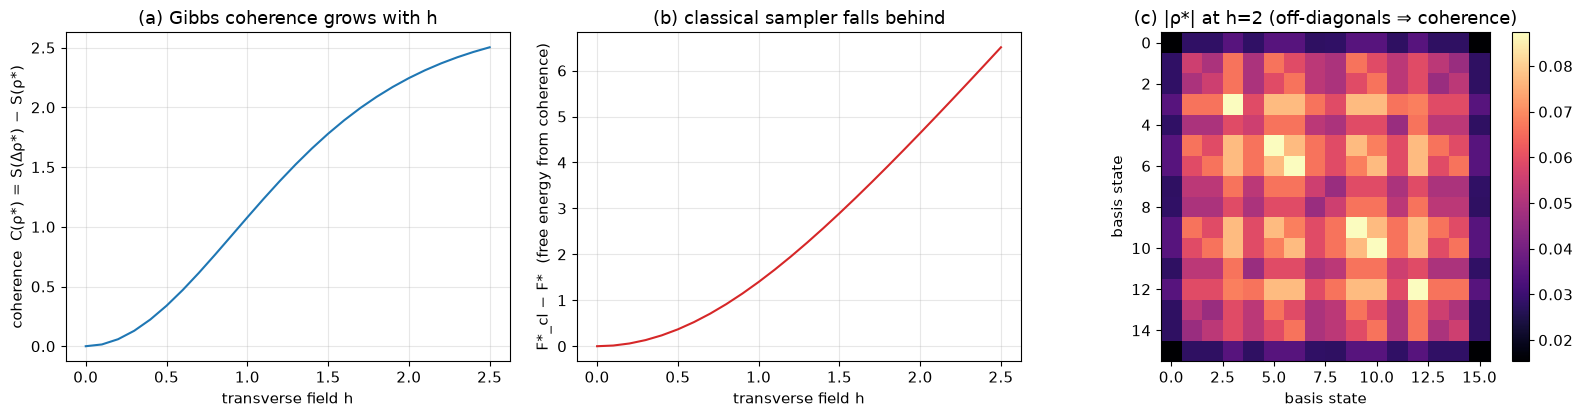

C(ρ*): h=0 → 0.000,  h=2.5 → 2.503


gap F*_cl−F*: h=0 → 0.000,  h=2.5 → 6.507   (off-diag mass |ρ*|: h=0=0.000, h=2=12.860)


In [2]:
# coherence + quantum/classical gap vs field h (T=1)
T = 1.0; hs = np.linspace(0, 2.5, 26)
Crel, gap = [], []
for h in hs:
    H = build_H(h); r, F, _ = gibbs(H, T); Crel.append(coh_rel(r)); gap.append(Fclassical(H, T) - F)
rho_lo = gibbs(build_H(0.0), T)[0].abs().numpy()
rho_hi = gibbs(build_H(2.0), T)[0].abs().numpy()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].plot(hs, Crel, color="#1f77b4"); ax[0].set_xlabel("transverse field h"); ax[0].set_ylabel("coherence  C(ρ*) = S(Δρ*) − S(ρ*)")
ax[0].set_title("(a) Gibbs coherence grows with h"); ax[0].grid(alpha=.3)
ax[1].plot(hs, gap, color="#d62728"); ax[1].set_xlabel("transverse field h"); ax[1].set_ylabel("F*_cl − F*  (free energy from coherence)")
ax[1].set_title("(b) classical sampler falls behind"); ax[1].grid(alpha=.3)
im = ax[2].imshow(rho_hi, cmap="magma"); ax[2].set_title("(c) |ρ*| at h=2 (off-diagonals ⇒ coherence)")
ax[2].set_xlabel("basis state"); ax[2].set_ylabel("basis state"); plt.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.savefig("qdc_expD.png", dpi=130, bbox_inches="tight"); plt.show()
print(f"C(ρ*): h=0 → {Crel[0]:.3f},  h=2.5 → {Crel[-1]:.3f}")
print(f"gap F*_cl−F*: h=0 → {gap[0]:.3f},  h=2.5 → {gap[-1]:.3f}   (off-diag mass |ρ*|: h=0={rho_lo.sum()-np.trace(rho_lo):.3f}, h=2={rho_hi.sum()-np.trace(rho_hi):.3f})")

## Experiment E — coherent flow reaches Gibbs; classical flow cannot (the payoff)

Train the general (coherent) dissipative flow and the dephased (classical) flow to minimise $F_T$ across a field sweep. The coherent flow should reach $F^*$ at every $h$ (KL$\to0$); the classical flow — which *can* make entropy but not coherence — floors at the $h$-independent $F_{cl}^*$, so its distance to Gibbs grows with $h$. This is a strictly quantum capability, not just mixed-vs-pure.

h=0.0 | F*= -3.958 F_coh= -3.958 F_cl*= -3.958 F_deph= -3.958 | KL_coh=0.000 KL_deph=0.000 | C_coh=0.000 C*=0.000


h=0.5 | F*= -4.325 F_coh= -4.325 F_cl*= -3.958 F_deph= -3.958 | KL_coh=0.000 KL_deph=0.367 | C_coh=0.339 C*=0.339


h=1.0 | F*= -5.356 F_coh= -5.356 F_cl*= -3.958 F_deph= -3.958 | KL_coh=0.000 KL_deph=1.398 | C_coh=1.079 C*=1.079


h=1.5 | F*= -6.850 F_coh= -6.850 F_cl*= -3.958 F_deph= -3.958 | KL_coh=0.000 KL_deph=2.893 | C_coh=1.779 C*=1.779


h=2.0 | F*= -8.597 F_coh= -8.597 F_cl*= -3.958 F_deph= -3.958 | KL_coh=0.000 KL_deph=4.640 | C_coh=2.245 C*=2.245


(trained in 184s)


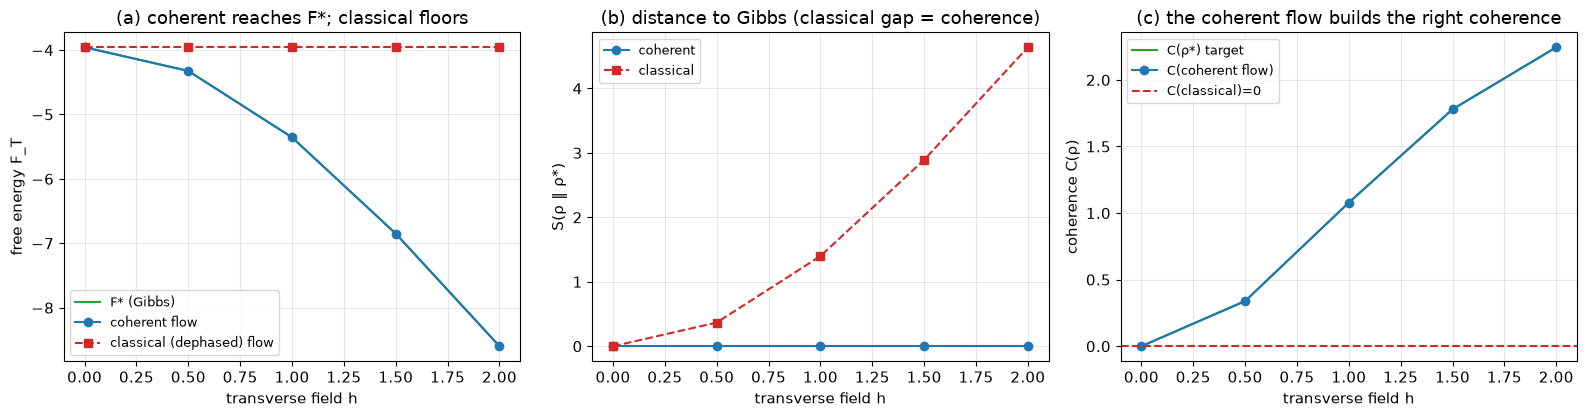

In [3]:
# train coherent vs dephased(classical) flows across the field sweep
T = 1.0; L = 4; hs_E = [0.0, 0.5, 1.0, 1.5, 2.0]
rows = []; t0 = time.time()
for h in hs_E:
    H = build_H(h); rstar, Fs, logstar = gibbs(H, T); Fcl = Fclassical(H, T)
    pc = train(coherent_flow, dS*dA, L, H, T); pd = train(dephased_flow, dS*dA, L, H, T)
    with torch.no_grad(): rc = coherent_flow(pc, rho0); rd = dephased_flow(pd, rho0)
    rows.append(dict(h=h, Fs=Fs, Fcl=Fcl, Fc=float(freeE(rc, H, T)), Fd=float(freeE(rd, H, T)),
                     KLc=rel_entropy(rc, logstar), KLd=rel_entropy(rd, logstar),
                     Cc=coh_rel(rc), Cstar=coh_rel(rstar)))
    print(f"h={h:.1f} | F*={Fs:7.3f} F_coh={rows[-1]['Fc']:7.3f} F_cl*={Fcl:7.3f} F_deph={rows[-1]['Fd']:7.3f}"
          f" | KL_coh={rows[-1]['KLc']:.3f} KL_deph={rows[-1]['KLd']:.3f} | C_coh={rows[-1]['Cc']:.3f} C*={rows[-1]['Cstar']:.3f}")
print(f"(trained in {time.time()-t0:.0f}s)")

hv = [r["h"] for r in rows]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].plot(hv, [r["Fs"] for r in rows], "-", color="#2ca02c", label="F* (Gibbs)")
ax[0].plot(hv, [r["Fc"] for r in rows], "o-", color="#1f77b4", label="coherent flow")
ax[0].plot(hv, [r["Fd"] for r in rows], "s--", color="#d62728", label="classical (dephased) flow")
ax[0].set_xlabel("transverse field h"); ax[0].set_ylabel("free energy F_T"); ax[0].legend(fontsize=9)
ax[0].set_title("(a) coherent reaches F*; classical floors"); ax[0].grid(alpha=.3)
ax[1].plot(hv, [r["KLc"] for r in rows], "o-", color="#1f77b4", label="coherent")
ax[1].plot(hv, [r["KLd"] for r in rows], "s--", color="#d62728", label="classical")
ax[1].set_xlabel("transverse field h"); ax[1].set_ylabel("S(ρ ‖ ρ*)"); ax[1].legend(fontsize=9)
ax[1].set_title("(b) distance to Gibbs (classical gap = coherence)"); ax[1].grid(alpha=.3)
ax[2].plot(hv, [r["Cstar"] for r in rows], "-", color="#2ca02c", label="C(ρ*) target")
ax[2].plot(hv, [r["Cc"] for r in rows], "o-", color="#1f77b4", label="C(coherent flow)")
ax[2].axhline(0, ls="--", color="#d62728", label="C(classical)=0")
ax[2].set_xlabel("transverse field h"); ax[2].set_ylabel("coherence C(ρ)"); ax[2].legend(fontsize=9)
ax[2].set_title("(c) the coherent flow builds the right coherence"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig("qdc_expE.png", dpi=130, bbox_inches="tight"); plt.show()

## Experiment F — building coherence layer by layer

At a fixed field ($h=1.5$), read out the coherent flow's state after each layer. It starts from the maximally-coherent pure $|+\rangle^{\otimes n}$ ($S=0$, but *too much* coherence of the wrong kind) and flows to the Gibbs state: free energy $F_T$ descends to $F^*$, entropy rises to $S(\rho^*)$ while the excess coherence *relaxes down* to $C(\rho^*)$, and the relative entropy to $\rho^*$ collapses. A coherent free-energy flow — the quantum-diffusion analog of the layerwise denoising in `free_energy_qaoa.ipynb`, but now reshaping both entropy *and* coherence.

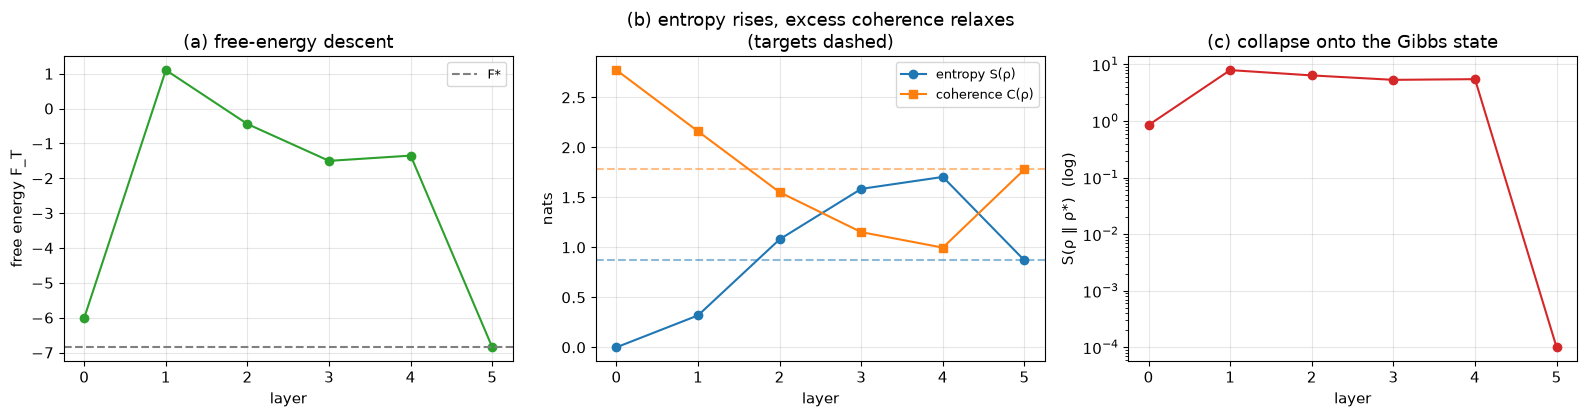

h=1.5: F -6.000→-6.850 (F*=-6.850); C(ρ) 2.773→1.779 (C*=1.779); KL→0.0000


In [4]:
# layerwise trajectory of the coherent flow at h=1.5
T = 1.0; L_F = 5; h = 1.5; H = build_H(h); rstar, Fs, logstar = gibbs(H, T)
ps = train(coherent_flow, dS*dA, L_F, H, T, steps=500, restarts=3)
with torch.no_grad(): _, hist = coherent_flow(ps, rho0, return_all=True)
Ft = [float(freeE(r, H, T)) for r in hist]; St = [float(vn(r)) for r in hist]
Ct = [coh_rel(r) for r in hist]; KLt = [rel_entropy(r, logstar) for r in hist]
xs = np.arange(len(hist))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].plot(xs, Ft, "-o", color="#2ca02c"); ax[0].axhline(Fs, ls="--", color="grey", label="F*")
ax[0].set_xlabel("layer"); ax[0].set_ylabel("free energy F_T"); ax[0].set_title("(a) free-energy descent"); ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)
ax[1].plot(xs, St, "-o", color="#1f77b4", label="entropy S(ρ)"); ax[1].axhline(float(vn(rstar)), ls="--", color="#1f77b4", alpha=.5)
ax[1].plot(xs, Ct, "-s", color="#ff7f0e", label="coherence C(ρ)"); ax[1].axhline(coh_rel(rstar), ls="--", color="#ff7f0e", alpha=.5)
ax[1].set_xlabel("layer"); ax[1].set_ylabel("nats"); ax[1].set_title("(b) entropy rises, excess coherence relaxes\n(targets dashed)"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
ax[2].semilogy(xs, np.clip(KLt, 1e-4, None), "-o", color="#d62728")
ax[2].set_xlabel("layer"); ax[2].set_ylabel("S(ρ ‖ ρ*)  (log)"); ax[2].set_title("(c) collapse onto the Gibbs state"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig("qdc_expF.png", dpi=130, bbox_inches="tight"); plt.show()
print(f"h={h}: F {Ft[0]:.3f}→{Ft[-1]:.3f} (F*={Fs:.3f}); C(ρ) {Ct[0]:.3f}→{Ct[-1]:.3f} (C*={coh_rel(rstar):.3f}); KL→{KLt[-1]:.4f}")

## Summary

With a non-commuting Hamiltonian the free-energy flow becomes **genuinely quantum** — it does something no classical Gibbs sampler can.

1. **The transverse-field Gibbs state is coherent** (Exp D). Coherence $C(\rho^*)$ grows $0\to2.50$ as $h\to2.5$, and the classical free energy $F_{cl}^*$ — which only sees the diagonal $ZZ$ part — is **$h$-independent** ($-3.958$), falling behind the true $F^*$ by a gap that reaches $6.5$. A classical sampler is blind to the transverse field.

2. **The coherent flow reaches Gibbs; the classical flow cannot** (Exp E, the payoff). The general dissipative flow hits $F^*$ with relative entropy to Gibbs $=0.000$ at *every* field strength, reproducing the exact Gibbs coherence ($C_{\text{flow}}=C^*$: $0.34,1.08,1.78,2.25$). The dephased (classical) flow — which *can* make entropy but not coherence — floors at $F_{cl}^*$, its distance to Gibbs growing $0\to0.37\to1.40\to2.89\to4.64$ with $h$. The gap *is* the coherence.

3. **Coherent free-energy flow, layer by layer** (Exp F). Starting from the maximally-coherent pure $|+\rangle^{\otimes n}$, the flow descends $F\to F^*$, raises entropy to $S(\rho^*)$, relaxes excess coherence to $C(\rho^*)$, and collapses onto the Gibbs state (KL $\to10^{-4}$).

**Takeaway.** This closes the arc of the free-energy series: (i) QAOA is coherent denoising but pure-state, so the entropy term is inert (`free_energy_qaoa`); (ii) learnable *dissipation* activates the entropy term and reaches classical Gibbs states (`quantum_free_energy_flow`); (iii) a *non-commuting* Hamiltonian makes the target carry coherence, and only a coherent dissipative flow can reach it — a task provably outside any classical sampler. Optimisation, thermal sampling, and coherent state preparation are one differentiable free-energy flow; the transverse field is the knob that turns "quantum diffusion" from a classical simulation into a quantum one. Next: a Lindblad continuous-time version with learnable jump operators, and scaling $n$ to map the coherence–capacity frontier.